In [1]:
#Import packages 

import numpy as np 
import pandas as pd 
import json 
import glob
import os
import csv
from statsmodels.tsa.seasonal import seasonal_decompose

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc

In [ ]:
from pathlib import Path

DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)


In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
# =====================================================
# Detailed season classification
# =====================================================

def assign_season(month):
    if month in [12, 1, 2, 3]:
        return 'Dry_Season'
    elif month in [4, 5, 6, 7]:
        return 'Major_Rainy_Season'
    elif month in [9, 10, 11]:
        return 'Minor_Rainy_Season'
    else:
        return 'Transition_Season'


# =====================================================
# Simpler season classification
# =====================================================

def assign_simple_season(month):
    if month in [12, 1, 2, 3]:
        return 'Dry_Season'
    elif month in [4, 5, 6, 7, 9, 10, 11]:
        return 'Rainy_Season'
    else:
        return 'Transition_Season'

### Sensor - CESI Mapping 

### using `rev1` version --> (2 CESI clusters instead of 3)  

In [4]:
### CESI Mapping here 
sensor_cesi_mapping = pd.read_csv(DATA_DIR / 'miscellaneous/sensor_cesi_mapping_rev1.csv').drop(columns=['Unnamed: 0'])

## *** Reading processed hourly data 

### `2022` & `2023` + `concat` 

In [5]:
processed_hourly_voltage_df_22 = pd.read_csv(DATA_DIR / 'processed_undervolt_data/undervolt_hourly_voltages_df_22.csv')

processed_hourly_voltage_df_23 = pd.read_csv(DATA_DIR / 'processed_undervolt_data/undervolt_hourly_voltages_df_23.csv')

combined_hourly_voltage_df = pd.concat([processed_hourly_voltage_df_22, processed_hourly_voltage_df_23], ignore_index=True)

### keep only sensors of interest 

In [6]:
sensor_of_interest_list = pd.read_csv(DATA_DIR / 'miscellaneous/common_sensors_22_23_rev4.csv')['respondent_id'].unique().tolist()

combined_hourly_voltage_df = combined_hourly_voltage_df[combined_hourly_voltage_df['sensor_id'].isin(sensor_of_interest_list)].reset_index(drop=True)

In [7]:
combined_hourly_voltage_df = combined_hourly_voltage_df.merge(sensor_cesi_mapping, on = 'sensor_id')

In [8]:
# combined_hourly_voltage_df

### *** Reading hourly temp data 

In [9]:
hourly_temperature = pd.read_csv(DATA_DIR / 'miscellaneous/hourly_temp_sites_of_interest.csv').drop(columns = ['Unnamed: 0'])

In [10]:
hourly_temperature

,time,ea_code9ch,site_id,Temp
0,2022-01-01 00:00:00,30200002,456,26.076052
1,2022-01-01 01:00:00,30200002,456,25.957307
2,2022-01-01 02:00:00,30200002,456,25.826359
3,2022-01-01 03:00:00,30200002,456,25.648857
4,2022-01-01 04:00:00,30200002,456,25.419535
...,...,...,...,...
4187275,2023-12-31 21:00:00,31300449,174,28.404043
4187276,2023-12-31 22:00:00,31300449,228,28.159903
4187277,2023-12-31 22:00:00,31300449,174,28.159903
4187278,2023-12-31 23:00:00,31300449,228,27.958948


### *** Merging with voltage data 

In [11]:
combined_hourly_voltage_df = combined_hourly_voltage_df.merge(hourly_temperature, on = ['time', 'site_id'])

combined_hourly_voltage_df = combined_hourly_voltage_df[['time', 'ea_code9ch',  'site_id', 'sensor_id', 'voltage', 'Temp', 'cesi_level']]

In [12]:
combined_hourly_voltage_df

,time,ea_code9ch,site_id,sensor_id,voltage,Temp,cesi_level
0,2022-01-01 00:00:00,30410207,1,bb3ff846,236.64,26.220942,Low
1,2022-01-01 01:00:00,30410207,1,bb3ff846,235.38,26.099647,Low
2,2022-01-01 02:00:00,30410207,1,bb3ff846,235.45,25.953452,Low
3,2022-01-01 03:00:00,30410207,1,bb3ff846,236.54,25.779780,Low
4,2022-01-01 04:00:00,30410207,1,bb3ff846,237.72,25.564437,Low
...,...,...,...,...,...,...,...
7098872,2023-12-31 09:00:00,30404073,473,3a67dee6,NaN,30.283167,High
7098873,2023-12-31 10:00:00,30404073,473,3a67dee6,NaN,31.422602,High
7098874,2023-12-31 11:00:00,30404073,473,3a67dee6,NaN,32.636075,High
7098875,2023-12-31 12:00:00,30404073,473,3a67dee6,NaN,33.649766,High


### Add season 

In [13]:
# Make sure time is datetime
combined_hourly_voltage_df['time'] = pd.to_datetime(
    combined_hourly_voltage_df['time']
)

# Extract month
combined_hourly_voltage_df['Month'] = (
    combined_hourly_voltage_df['time'].dt.month
)

# =====================================================
# Detailed season classification
# =====================================================

combined_hourly_voltage_df['season_detailed'] = (
    combined_hourly_voltage_df['Month']
    .apply(assign_season)
)

# =====================================================
# Simpler season classification
# =====================================================

combined_hourly_voltage_df['season_simple'] = (
    combined_hourly_voltage_df['Month']
    .apply(assign_simple_season)
)

In [14]:
combined_hourly_voltage_df

,time,ea_code9ch,site_id,sensor_id,voltage,Temp,cesi_level,Month,season_detailed,season_simple
0,2022-01-01 00:00:00,30410207,1,bb3ff846,236.64,26.220942,Low,1,Dry_Season,Dry_Season
1,2022-01-01 01:00:00,30410207,1,bb3ff846,235.38,26.099647,Low,1,Dry_Season,Dry_Season
2,2022-01-01 02:00:00,30410207,1,bb3ff846,235.45,25.953452,Low,1,Dry_Season,Dry_Season
3,2022-01-01 03:00:00,30410207,1,bb3ff846,236.54,25.779780,Low,1,Dry_Season,Dry_Season
4,2022-01-01 04:00:00,30410207,1,bb3ff846,237.72,25.564437,Low,1,Dry_Season,Dry_Season
...,...,...,...,...,...,...,...,...,...,...
7098872,2023-12-31 09:00:00,30404073,473,3a67dee6,NaN,30.283167,High,12,Dry_Season,Dry_Season
7098873,2023-12-31 10:00:00,30404073,473,3a67dee6,NaN,31.422602,High,12,Dry_Season,Dry_Season
7098874,2023-12-31 11:00:00,30404073,473,3a67dee6,NaN,32.636075,High,12,Dry_Season,Dry_Season
7098875,2023-12-31 12:00:00,30404073,473,3a67dee6,NaN,33.649766,High,12,Dry_Season,Dry_Season


### Summary Stats -> Hourly Voltages 

In [15]:
percentiles_df = (
    combined_hourly_voltage_df['voltage']
    .quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .reset_index()
)

percentiles_df.columns = ['percentile', 'voltage']
percentiles_df['percentile'] = (
    percentiles_df['percentile'] * 100
).astype(int)

In [16]:
percentiles_df

,percentile,voltage
0,1,183.14
1,5,204.31
2,10,212.90
3,25,224.16
4,50,234.09
5,75,241.94
6,90,248.47
7,95,252.19
8,99,258.46


In [17]:
combined_hourly_voltage_df['voltage'].quantile(0.062)

np.float64(207.02)

### low voltage threshold: 207V (undervolt threshold): 6.2 percentile 

In [18]:
# OR 

# propose low voltage threshold - 5th percentile seems reasonable -> for temp I am looking at the 95th percentile 

In [19]:
# (why am I now seeing very few undervoltages?) -- possibly cos of the 'within hour definition'? 

# previously, it was spanning multiple...but still... 

# the logit I run was for 207V anyways and the results were not gidigidi -> so should be worse if I reduce it 

## *** Plots 

### Plot hourly voltages (all) 

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_voltage_timeseries_envelope(
    df,
    start_time=None,
    end_time=None,
    site_ids=None,
    cesi_level=None,          # 'Low', 'Medium', 'High', or None
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    figsize=(15, 5),
    linewidth=2.5,
    alpha_band=0.25,
    line_color=None,
    band_color=None,
    ylabel='Voltage (V)',
    xlabel='Time',
    legend_loc='best',
    legend_bbox=None,
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5, 
    ylim=None
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if cesi_level is not None:
        plot_df = plot_df[plot_df['cesi_level'] == cesi_level]

    if start_time is not None:
        plot_df = plot_df[plot_df['time'] >= pd.to_datetime(start_time)]

    if end_time is not None:
        plot_df = plot_df[plot_df['time'] <= pd.to_datetime(end_time)]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['time', 'voltage'])

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    cesi_colors = {
        'Low': {
            'line': '#6a51a3',
            'band': '#bcbddc'
        },
        'Medium': {
            'line': '#238b45',
            'band': '#a1d99b'
        },
        'High': {
            'line': '#8c2d04',
            'band': '#fdbb84'
        }
    }

    if line_color is None:
        line_color = cesi_colors.get(
            cesi_level, {}
        ).get('line', 'black')

    if band_color is None:
        band_color = cesi_colors.get(
            cesi_level, {}
        ).get('band', 'gray')

    grouped = (
        plot_df
        .groupby('time')['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
    )

    plt.figure(figsize=figsize)
    ax = plt.gca()

    ax.fill_between(
        grouped['time'],
        grouped['lower'],
        grouped['upper'],
        color=band_color,
        alpha=alpha_band,
        label=f'{int(lower_q*100)}th–{int(upper_q*100)}th percentile'
    )

    label_prefix = f'{cesi_level} CESI ' if cesi_level is not None else ''

    ax.plot(
        grouped['time'],
        grouped['center_value'],
        color=line_color,
        linewidth=linewidth,
        label=f'{label_prefix}{center.capitalize()}'
    )

    if show_voltage_bounds:

        lower_bound = nominal_voltage * (1 - tolerance)
        upper_bound = nominal_voltage * (1 + tolerance)

        ax.axhline(
            lower_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=f'Lower Bound ({lower_bound:.0f} V)'
        )

        ax.axhline(
            upper_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=f'Upper Bound ({upper_bound:.0f} V)'
        )

    ax.set_xlabel(
        xlabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    title_parts = []

    if cesi_level is not None:
        title_parts.append(f'{cesi_level} CESI')

    if site_ids is not None:
        title_parts.append(f'{len(site_ids)} selected site(s)')

    if len(title_parts) > 0:
        ax.set_title(
            ' | '.join(title_parts),
            fontsize=14,
            fontweight='bold'
        )
        
    # -------------------------
    # Optional y limits
    # -------------------------
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.legend(
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    sns.despine()
    plt.tight_layout()
    plt.show()

    return grouped

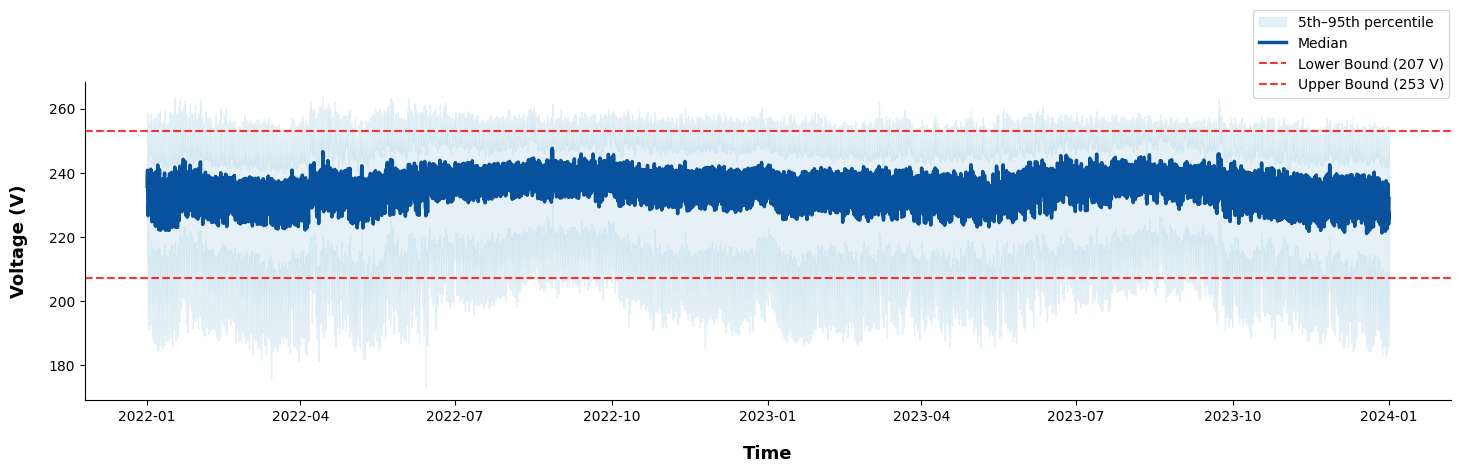

In [21]:
summary_all = plot_voltage_timeseries_envelope(
    combined_hourly_voltage_df,
    cesi_level=None, 
    # start_time='2022-01-15',
    # end_time='2022-02-15',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    show_voltage_bounds=True,
    line_color='#08519c',
    band_color='#9ecae1',
    legend_loc='upper left',
    legend_bbox=(0.85, 1.25)
)

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_daily_voltage_temp_stacked(
    df,
    start_time=None,
    end_time=None,
    site_ids=None,
    cesi_level=None,
    voltage_col='voltage',
    temp_col='Temp',
    center='median',
    lower_q=0.10,
    upper_q=0.90,
    ignore_zero=True,
    figsize=(15, 8),
    voltage_line_color='#08519c',
    voltage_band_color='#9ecae1',
    temp_line_color='#f16913',
    temp_band_color='#fdd0a2',
    linewidth=2.5,
    alpha_band=0.25,
    voltage_ylabel='Voltage (V)',
    temp_ylabel='Temperature (°C)',
    xlabel='Date',
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,
    show_temp_threshold=True,
    temp_threshold=32,
    temp_threshold_color='darkred',
    temp_threshold_linestyle='--',
    temp_threshold_linewidth=1.5,
    temp_threshold_label='WHO Thermal Comfort Threshold (32°C)',
    voltage_ylim=None,
    temp_ylim=None,
    legend_loc='upper left',
    legend_bbox=None,
    sharex=True
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    # -------------------------
    # Filtering
    # -------------------------
    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if cesi_level is not None:
        plot_df = plot_df[plot_df['cesi_level'] == cesi_level]

    if start_time is not None:
        plot_df = plot_df[plot_df['time'] >= pd.to_datetime(start_time)]

    if end_time is not None:
        plot_df = plot_df[plot_df['time'] <= pd.to_datetime(end_time)]

    if ignore_zero:
        plot_df = plot_df[plot_df[voltage_col] != 0]

    plot_df = plot_df.dropna(subset=['time'])
    plot_df['date'] = plot_df['time'].dt.floor('D')

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    percentile_label = (
    f'{int(lower_q * 100)}th - '
    f'{int(upper_q * 100)}th percentile'
    )

    # -------------------------
    # Daily voltage summaries
    # -------------------------
    voltage_grouped = (
        plot_df
        .dropna(subset=[voltage_col])
        .groupby('date')[voltage_col]
        .agg(
            voltage_center=center,
            voltage_lower=lambda x: x.quantile(lower_q),
            voltage_upper=lambda x: x.quantile(upper_q),
            voltage_n='count'
        )
        .reset_index()
    )

    # -------------------------
    # Daily temperature summaries
    # -------------------------
    temp_grouped = (
        plot_df
        .dropna(subset=[temp_col])
        .groupby('date')[temp_col]
        .agg(
            temp_center=center,
            temp_lower=lambda x: x.quantile(lower_q),
            temp_upper=lambda x: x.quantile(upper_q),
            temp_n='count'
        )
        .reset_index()
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=sharex
    )

    ax_temp = axes[0]
    ax_volt = axes[1]

    # =================================================
    # TEMPERATURE SUBPLOT
    # =================================================
    ax_temp.fill_between(
        temp_grouped['date'],
        temp_grouped['temp_lower'],
        temp_grouped['temp_upper'],
        color=temp_band_color,
        alpha=alpha_band,
        label=percentile_label
    )

    ax_temp.plot(
        temp_grouped['date'],
        temp_grouped['temp_center'],
        color=temp_line_color,
        linewidth=linewidth,
        label=f'Daily Temperature {center.capitalize()}'
    )

    if show_temp_threshold:
        ax_temp.axhline(
            temp_threshold,
            color=temp_threshold_color,
            linestyle=temp_threshold_linestyle,
            linewidth=temp_threshold_linewidth,
            alpha=0.9,
            label=temp_threshold_label
        )

    ax_temp.set_ylabel(
        temp_ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15,
        color=temp_line_color
    )

    ax_temp.tick_params(
        axis='y',
        colors=temp_line_color,
        labelsize=11,
        width=2
    )

    ax_temp.tick_params(axis='x', labelsize=11)

    ax_temp.spines['left'].set_color(temp_line_color)
    ax_temp.spines['left'].set_linewidth(1.5)

    if temp_ylim is not None:
        ax_temp.set_ylim(temp_ylim)

    # Temperature legend order
    temp_handles, temp_labels = ax_temp.get_legend_handles_labels()

    temp_order = [
        temp_labels.index(f'Daily Temperature {center.capitalize()}'),
        temp_labels.index(percentile_label)
    ]

    if show_temp_threshold:
        temp_order.append(temp_labels.index(temp_threshold_label))

    ax_temp.legend(
        [temp_handles[i] for i in temp_order],
        [temp_labels[i] for i in temp_order],
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    # =================================================
    # VOLTAGE SUBPLOT
    # =================================================
    ax_volt.fill_between(
        voltage_grouped['date'],
        voltage_grouped['voltage_lower'],
        voltage_grouped['voltage_upper'],
        color=voltage_band_color,
        alpha=alpha_band,
        label=percentile_label
    )

    ax_volt.plot(
        voltage_grouped['date'],
        voltage_grouped['voltage_center'],
        color=voltage_line_color,
        linewidth=linewidth,
        label=f'Daily Voltage {center.capitalize()}'
    )

    if show_voltage_bounds:
        lower_bound = nominal_voltage * (1 - tolerance)
        upper_bound = nominal_voltage * (1 + tolerance)

        ax_volt.axhline(
            lower_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label='Lower Voltage Bound'
        )

        ax_volt.axhline(
            upper_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label='Upper Voltage Bound'
        )

    ax_volt.set_xlabel(
        xlabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    ax_volt.set_ylabel(
        voltage_ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15,
        color=voltage_line_color
    )

    ax_volt.tick_params(
        axis='y',
        colors=voltage_line_color,
        labelsize=11,
        width=2
    )

    ax_volt.tick_params(axis='x', labelsize=11)

    ax_volt.spines['left'].set_color(voltage_line_color)
    ax_volt.spines['left'].set_linewidth(1.5)

    if voltage_ylim is not None:
        ax_volt.set_ylim(voltage_ylim)

    # Voltage legend order
    volt_handles, volt_labels = ax_volt.get_legend_handles_labels()

    volt_order = [
        volt_labels.index(f'Daily Voltage {center.capitalize()}'),
        volt_labels.index(percentile_label)
    ]

    if show_voltage_bounds:
        volt_order.extend([
            volt_labels.index('Lower Voltage Bound'),
            volt_labels.index('Upper Voltage Bound')
        ])

    ax_volt.legend(
        [volt_handles[i] for i in volt_order],
        [volt_labels[i] for i in volt_order],
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    # -------------------------
    # Clean styling
    # -------------------------
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    if cesi_level is not None:
        fig.suptitle(
            f'{cesi_level} CESI',
            fontsize=15,
            fontweight='bold',
            y=1.02
        )

    plt.tight_layout()
    plt.show()

    return voltage_grouped, temp_grouped

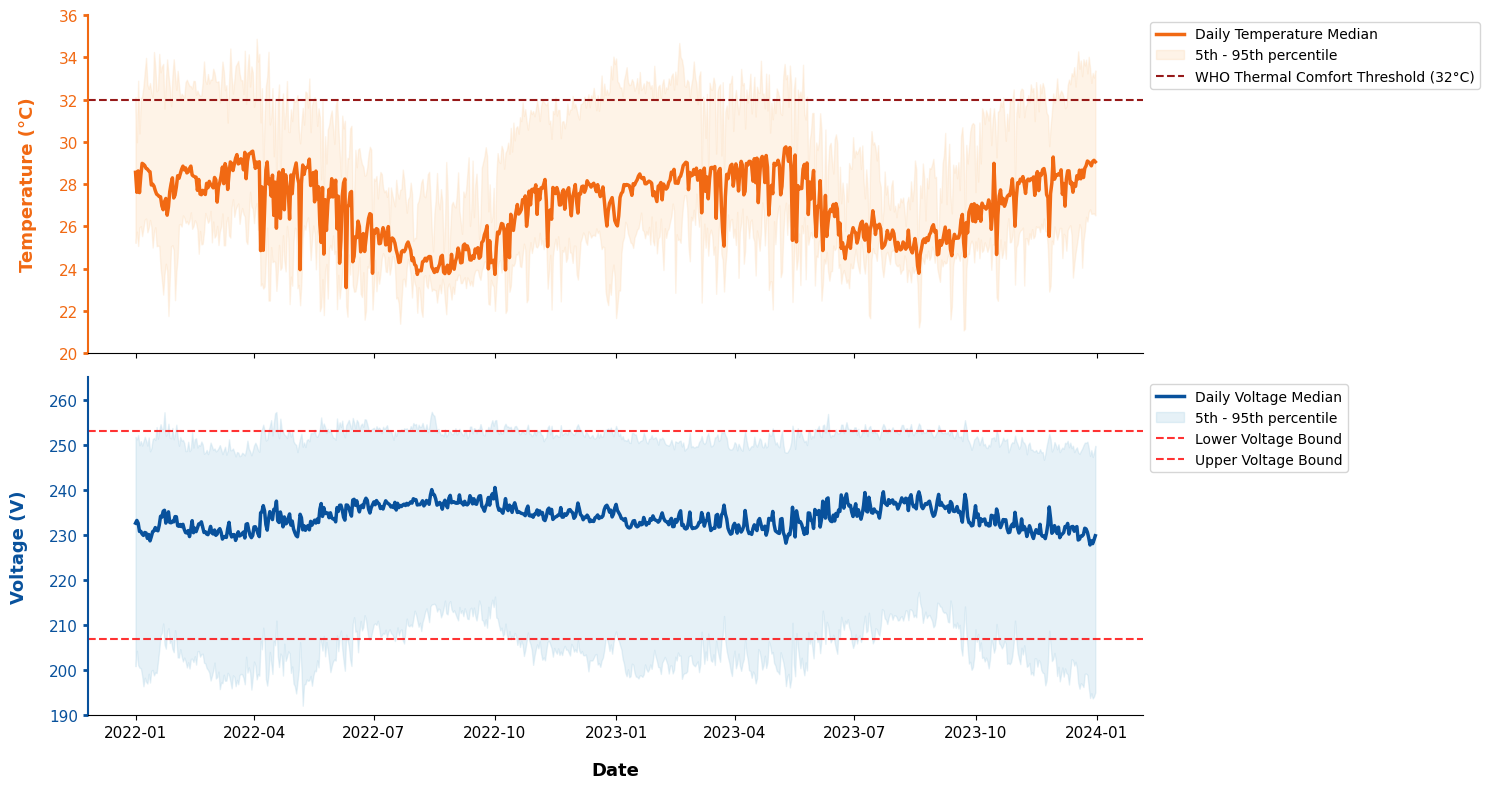

In [23]:
daily_voltage_summary, daily_temp_summary = plot_daily_voltage_temp_stacked(
    combined_hourly_voltage_df,
    figsize=(15, 8),
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    voltage_ylim=(190, 265),
    temp_ylim=(20, 36), 
    legend_loc='upper left',
    legend_bbox=(1,1),
)

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_resampled_voltage_temp_stacked(
    df,
    start_time=None,
    end_time=None,
    site_ids=None,
    cesi_level=None,

    voltage_col='voltage',
    temp_col='Temp',

    resample_rule='D',

    center='median',
    lower_q=0.10,
    upper_q=0.90,

    ignore_zero=True,

    figsize=(15, 8),

    voltage_line_color='#08519c',
    voltage_band_color='#9ecae1',

    temp_line_color='#f16913',
    temp_band_color='#fdd0a2',

    linewidth=2.5,
    alpha_band=0.25,

    voltage_ylabel='Voltage (V)',
    temp_ylabel='Temperature (°C)',
    xlabel='Time',

    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,

    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,

    show_temp_threshold=True,
    temp_threshold=32,
    temp_threshold_color='darkred',
    temp_threshold_linestyle='--',
    temp_threshold_linewidth=1.5,
    temp_threshold_label='WHO Thermal Comfort Threshold (32°C)',

    voltage_ylim=None,
    temp_ylim=None,

    legend_loc='upper left',
    legend_bbox=None,

    sharex=True
):

    plot_df = df.copy()

    plot_df['time'] = pd.to_datetime(
        plot_df['time']
    )

    # -------------------------
    # Filtering
    # -------------------------
    if site_ids is not None:

        plot_df = plot_df[
            plot_df['site_id'].isin(site_ids)
        ]

    if cesi_level is not None:

        plot_df = plot_df[
            plot_df['cesi_level'] == cesi_level
        ]

    if start_time is not None:

        plot_df = plot_df[
            plot_df['time'] >= pd.to_datetime(start_time)
        ]

    if end_time is not None:

        plot_df = plot_df[
            plot_df['time'] <= pd.to_datetime(end_time)
        ]

    if ignore_zero:

        plot_df = plot_df[
            plot_df[voltage_col] != 0
        ]

    plot_df = plot_df.dropna(subset=['time'])

    # -------------------------
    # Resampling setup
    # -------------------------
    plot_df = plot_df.sort_values('time')

    plot_df = plot_df.set_index('time')

    # -------------------------
    # Validate center
    # -------------------------
    if center not in ['mean', 'median']:

        raise ValueError(
            "center must be either 'mean' or 'median'"
        )

    percentile_label = (
        f'{int(lower_q * 100)}th - '
        f'{int(upper_q * 100)}th percentile'
    )

    # -------------------------
    # Resampled voltage summaries
    # -------------------------
    voltage_grouped = (
        plot_df
        .dropna(subset=[voltage_col])
        .resample(resample_rule)[voltage_col]
        .agg(
            voltage_center=center,
            voltage_lower=lambda x: x.quantile(lower_q),
            voltage_upper=lambda x: x.quantile(upper_q),
            voltage_n='count'
        )
        .reset_index()
    )

    # -------------------------
    # Resampled temperature summaries
    # -------------------------
    temp_grouped = (
        plot_df
        .dropna(subset=[temp_col])
        .resample(resample_rule)[temp_col]
        .agg(
            temp_center=center,
            temp_lower=lambda x: x.quantile(lower_q),
            temp_upper=lambda x: x.quantile(upper_q),
            temp_n='count'
        )
        .reset_index()
    )

    # -------------------------
    # Figure
    # -------------------------
    fig, axes = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=sharex
    )

    ax_temp = axes[0]
    ax_volt = axes[1]

    # =================================================
    # TEMPERATURE SUBPLOT
    # =================================================

    ax_temp.fill_between(
        temp_grouped['time'],
        temp_grouped['temp_lower'],
        temp_grouped['temp_upper'],
        color=temp_band_color,
        alpha=alpha_band,
        label=percentile_label
    )

    ax_temp.plot(
        temp_grouped['time'],
        temp_grouped['temp_center'],
        color=temp_line_color,
        linewidth=linewidth,
        label=f'{resample_rule} Temperature {center.capitalize()}'
    )

    if show_temp_threshold:

        ax_temp.axhline(
            temp_threshold,
            color=temp_threshold_color,
            linestyle=temp_threshold_linestyle,
            linewidth=temp_threshold_linewidth,
            alpha=0.9,
            label=temp_threshold_label
        )

    ax_temp.set_ylabel(
        temp_ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15,
        color=temp_line_color
    )

    ax_temp.tick_params(
        axis='y',
        colors=temp_line_color,
        labelsize=11,
        width=2
    )

    ax_temp.tick_params(
        axis='x',
        labelsize=11
    )

    ax_temp.spines['left'].set_color(
        temp_line_color
    )

    ax_temp.spines['left'].set_linewidth(1.5)

    if temp_ylim is not None:

        ax_temp.set_ylim(temp_ylim)

    # Temperature legend order
    temp_handles, temp_labels = (
        ax_temp.get_legend_handles_labels()
    )

    temp_order = [
        temp_labels.index(
            f'{resample_rule} Temperature {center.capitalize()}'
        ),
        temp_labels.index(percentile_label)
    ]

    if show_temp_threshold:

        temp_order.append(
            temp_labels.index(temp_threshold_label)
        )

    ax_temp.legend(
        [temp_handles[i] for i in temp_order],
        [temp_labels[i] for i in temp_order],
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    # =================================================
    # VOLTAGE SUBPLOT
    # =================================================

    ax_volt.fill_between(
        voltage_grouped['time'],
        voltage_grouped['voltage_lower'],
        voltage_grouped['voltage_upper'],
        color=voltage_band_color,
        alpha=alpha_band,
        label=percentile_label
    )

    ax_volt.plot(
        voltage_grouped['time'],
        voltage_grouped['voltage_center'],
        color=voltage_line_color,
        linewidth=linewidth,
        label=f'{resample_rule} Voltage {center.capitalize()}'
    )

    if show_voltage_bounds:

        lower_bound = (
            nominal_voltage * (1 - tolerance)
        )

        upper_bound = (
            nominal_voltage * (1 + tolerance)
        )

        ax_volt.axhline(
            lower_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label='Lower Voltage Bound'
        )

        ax_volt.axhline(
            upper_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label='Upper Voltage Bound'
        )

    ax_volt.set_xlabel(
        xlabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    ax_volt.set_ylabel(
        voltage_ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15,
        color=voltage_line_color
    )

    ax_volt.tick_params(
        axis='y',
        colors=voltage_line_color,
        labelsize=11,
        width=2
    )

    ax_volt.tick_params(
        axis='x',
        labelsize=11
    )

    ax_volt.spines['left'].set_color(
        voltage_line_color
    )

    ax_volt.spines['left'].set_linewidth(1.5)

    if voltage_ylim is not None:

        ax_volt.set_ylim(voltage_ylim)

    # Voltage legend order
    volt_handles, volt_labels = (
        ax_volt.get_legend_handles_labels()
    )

    volt_order = [
        volt_labels.index(
            f'{resample_rule} Voltage {center.capitalize()}'
        ),
        volt_labels.index(percentile_label)
    ]

    if show_voltage_bounds:

        volt_order.extend([
            volt_labels.index('Lower Voltage Bound'),
            volt_labels.index('Upper Voltage Bound')
        ])

    ax_volt.legend(
        [volt_handles[i] for i in volt_order],
        [volt_labels[i] for i in volt_order],
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    # -------------------------
    # Clean styling
    # -------------------------
    for ax in axes:

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    if cesi_level is not None:

        fig.suptitle(
            f'{cesi_level} CESI',
            fontsize=15,
            fontweight='bold',
            y=1.02
        )

    plt.tight_layout()
    plt.show()

    return voltage_grouped, temp_grouped

In [25]:
# daily_voltage_summary, daily_temp_summary = plot_resampled_voltage_temp_stacked(
#     combined_hourly_voltage_df,
#     figsize=(15, 8),
#     resample_rule='7H',
#     center='median',
#     lower_q=0.05,
#     upper_q=0.95,
#     voltage_ylim=(190, 265),
#     temp_ylim=(20, 36), 
#     legend_loc='upper left',
#     legend_bbox=(1,1),
# )

In [26]:
# daily_voltage_summary, daily_temp_summary = plot_resampled_voltage_temp_stacked(
#     combined_hourly_voltage_df,
#     figsize=(15, 8),
#     resample_rule='12H',
#     center='median',
#     lower_q=0.05,
#     upper_q=0.95,
#     voltage_ylim=(190, 265),
#     temp_ylim=(20, 36), 
#     legend_loc='upper left',
#     legend_bbox=(1,1),
# )

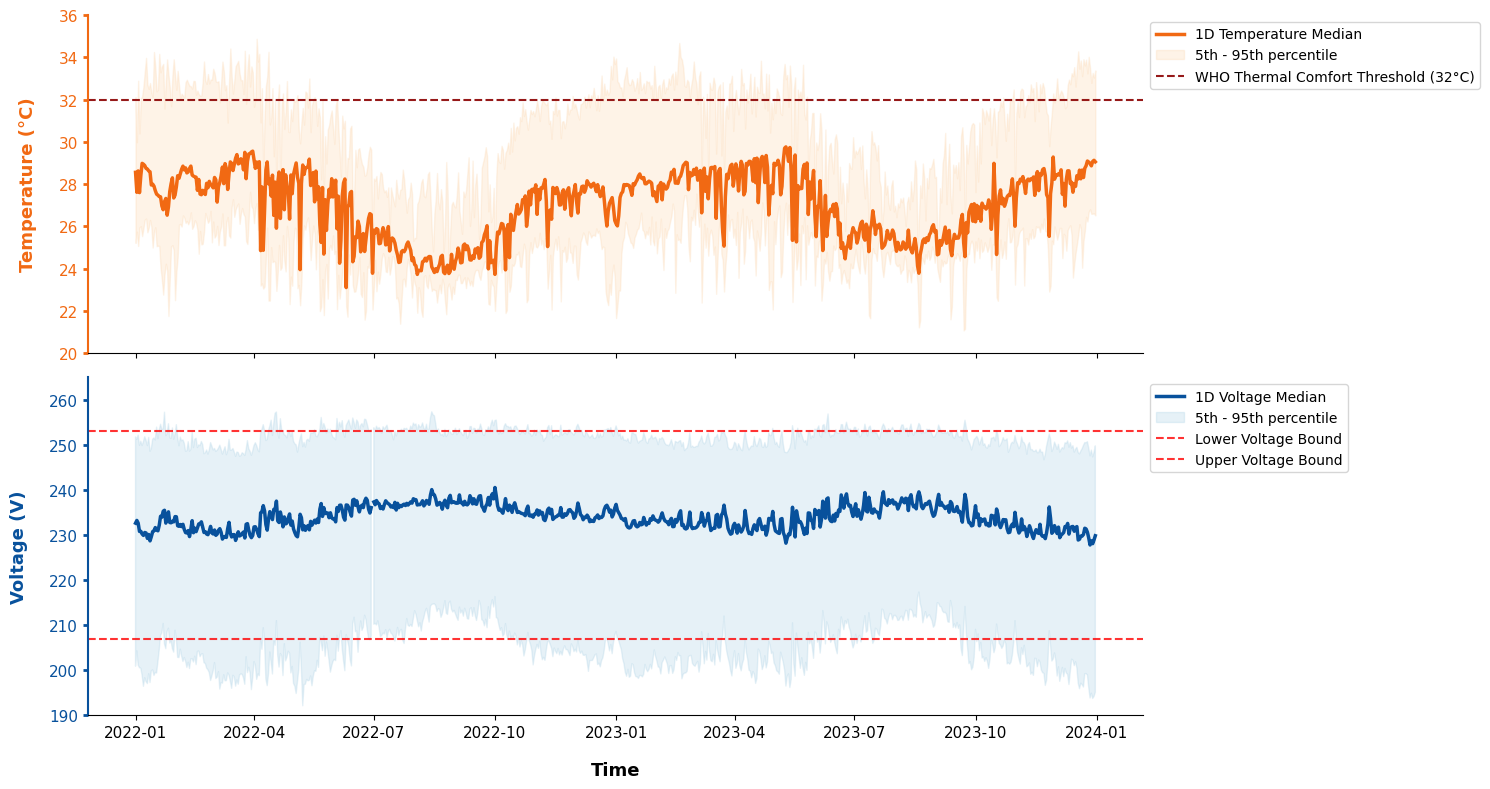

In [27]:
daily_voltage_summary, daily_temp_summary = plot_resampled_voltage_temp_stacked(
    combined_hourly_voltage_df,
    figsize=(15, 8),
    resample_rule='1D',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    voltage_ylim=(190, 265),
    temp_ylim=(20, 36), 
    legend_loc='upper left',
    legend_bbox=(1,1),
)

In [28]:
# daily_voltage_summary, daily_temp_summary = plot_resampled_voltage_temp_stacked(
#     combined_hourly_voltage_df,
#     figsize=(15, 8),
#     resample_rule='3D',
#     center='median',
#     lower_q=0.05,
#     upper_q=0.95,
#     voltage_ylim=(190, 265),
#     temp_ylim=(20, 36), 
#     legend_loc='upper left',
#     legend_bbox=(1,1),
# )

In [29]:
# daily_voltage_summary, daily_temp_summary = plot_resampled_voltage_temp_stacked(
#     combined_hourly_voltage_df,
#     figsize=(15, 8),
#     resample_rule='W',
#     center='median',
#     lower_q=0.05,
#     upper_q=0.95,
#     voltage_ylim=(190, 265),
#     temp_ylim=(20, 36), 
#     legend_loc='upper left',
#     legend_bbox=(1,1),
# )

In [30]:
# daily_voltage_summary, daily_temp_summary = plot_resampled_voltage_temp_stacked(
#     combined_hourly_voltage_df,
#     figsize=(15, 8),
#     resample_rule='MS',
#     center='median',
#     lower_q=0.05,
#     upper_q=0.95,
#     voltage_ylim=(190, 265),
#     temp_ylim=(20, 36), 
#     legend_loc='upper left',
#     legend_bbox=(1,1),
# )

### Histogram 

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

def plot_voltage_histogram(
    df,
    site_ids=None,
    cesi_level=None,          # 'Low', 'High', or None
    bins=40,
    ignore_zero=True,
    normalize=True,
    figsize=(10, 6),
    color=None,
    alpha=0.7,
    show_kde=True,
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,
    xlabel='Hourly Voltage (V)',
    ylabel=None,
    legend_loc='best',
    legend_bbox=None, 
    xlim=None, 
    save_path=None,         # e.g. 'figures/voltage_hist.png'
    dpi=300
):

    plot_df = df.copy()

    # -------------------------
    # Optional site filtering
    # -------------------------
    if site_ids is not None:
        plot_df = plot_df[
            plot_df['site_id'].isin(site_ids)
        ]

    # -------------------------
    # Optional CESI filtering
    # -------------------------
    if cesi_level is not None:
        plot_df = plot_df[
            plot_df['cesi_level'] == cesi_level
        ]

    # -------------------------
    # Remove zero voltages
    # -------------------------
    if ignore_zero:
        plot_df = plot_df[
            plot_df['voltage'] != 0
        ]

    plot_df = plot_df.dropna(subset=['voltage'])

    # -------------------------
    # Auto colors
    # -------------------------
    cesi_colors = {
        'Low': '#6a51a3',
        'Medium': '#238b45',
        'High': '#8c2d04'
    }

    if color is None:
        color = cesi_colors.get(
            cesi_level,
            '#3182bd'
        )

    # -------------------------
    # Histogram stat
    # -------------------------
    stat = 'percent' if normalize else 'count'

    if ylabel is None:
        ylabel = (
            'Percentage of Observations'
            if normalize
            else 'Count'
        )

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=figsize)

    ax = sns.histplot(
        data=plot_df,
        x='voltage',
        bins=bins,
        kde=show_kde,
        stat=stat,
        color=color,
        alpha=alpha
    )

    # -------------------------
    # Voltage bounds
    # -------------------------
    if show_voltage_bounds:

        lower_bound = nominal_voltage * (1 - tolerance)
        upper_bound = nominal_voltage * (1 + tolerance)

        ax.axvline(
            lower_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            label=f'Low Voltage Threshold ({lower_bound:.0f} V)'
        )

        # ax.axvline(
        #     upper_bound,
        #     color=bounds_color,
        #     linestyle=bounds_linestyle,
        #     linewidth=bounds_linewidth,
        #     label=f'Upper Bound ({upper_bound:.0f} V)'
        # )

    # -------------------------
    # Title
    # -------------------------
    if cesi_level is not None:
        ax.set_title(
            f'',
            fontsize=14,
            fontweight='bold'
        )

    # -------------------------
    # Labels
    # -------------------------
    ax.set_xlabel(
        xlabel,
        fontsize=15,
        fontweight='bold',
        labelpad=15
    )

    ax.set_ylabel(
        ylabel,
        fontsize=15,
        fontweight='bold',
        labelpad=15
    )

    if normalize:
        ax.yaxis.set_major_formatter(
            PercentFormatter()
        )

    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

    # -------------------------
    # Optional x limits
    # -------------------------
    if xlim is not None:
        ax.set_xlim(xlim)

    ax.legend(
        loc=legend_loc,
        bbox_to_anchor=legend_bbox, 
        fontsize=12
    )

    sns.despine()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

    return plot_df

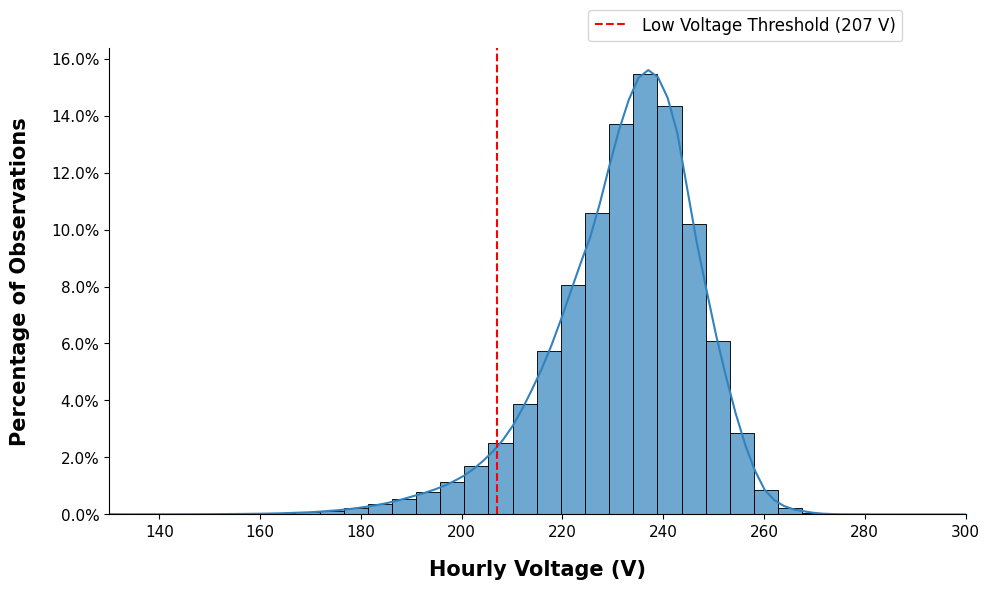

In [58]:
all_volt_histogram = plot_voltage_histogram(
    combined_hourly_voltage_df,
    cesi_level = None,
    bins = 80, 
    xlim = (130, 300), 
    legend_loc='upper left',
    legend_bbox=(0.55, 1.10), 
    save_path = 'hourly_volt_distribution.png'
)

## *** Hour of the day 

### Hourly summary (w/ percentiles) - `All Hours` 

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_voltage_by_hour_of_day(
    df,
    site_ids=None,
    cesi_level=None,          # 'Low', 'High', or None
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    figsize=(12, 6),
    linewidth=2.5,
    alpha_band=0.25,
    line_color=None,
    band_color=None,
    ylabel='Voltage (V)',
    xlabel='Hour of Day',
    legend_loc='best',
    legend_bbox=None,
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,
    ylim=None
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    # -------------------------
    # Filter sites
    # -------------------------
    if site_ids is not None:
        plot_df = plot_df[
            plot_df['site_id'].isin(site_ids)
        ]

    # -------------------------
    # Filter CESI level
    # -------------------------
    if cesi_level is not None:
        plot_df = plot_df[
            plot_df['cesi_level'] == cesi_level
        ]

    # -------------------------
    # Remove zero voltages
    # -------------------------
    if ignore_zero:
        plot_df = plot_df[
            plot_df['voltage'] != 0
        ]

    plot_df = plot_df.dropna(
        subset=['time', 'voltage']
    )

    # -------------------------
    # Auto colors by CESI
    # -------------------------
    cesi_colors = {
        'Low': {
            'line': '#6a51a3',
            'band': '#bcbddc'
        },
        'Medium': {
            'line': '#238b45',
            'band': '#a1d99b'
        },
        'High': {
            'line': '#8c2d04',
            'band': '#fdbb84'
        }
    }

    if line_color is None:
        line_color = cesi_colors.get(
            cesi_level, {}
        ).get('line', 'black')

    if band_color is None:
        band_color = cesi_colors.get(
            cesi_level, {}
        ).get('band', 'gray')

    # -------------------------
    # Hour of day
    # -------------------------
    plot_df['hour'] = plot_df['time'].dt.hour

    # -------------------------
    # Validate center argument
    # -------------------------
    if center not in ['mean', 'median']:
        raise ValueError(
            "center must be either 'mean' or 'median'"
        )

    # -------------------------
    # Aggregate across sensors
    # -------------------------
    grouped = (
        plot_df
        .groupby('hour')['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
        .sort_values('hour')
    )

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=figsize)
    ax = plt.gca()

    label_prefix = (
        f'{cesi_level} CESI '
        if cesi_level is not None
        else ''
    )

    ax.fill_between(
        grouped['hour'],
        grouped['lower'],
        grouped['upper'],
        color=band_color,
        alpha=alpha_band,
        label=f'{int(lower_q*100)}th–{int(upper_q*100)}th percentile'
    )

    ax.plot(
        grouped['hour'],
        grouped['center_value'],
        color=line_color,
        linewidth=linewidth,
        marker='o',
        label=f'{label_prefix}{center.capitalize()}'
    )

    # -------------------------
    # Voltage bounds
    # -------------------------
    if show_voltage_bounds:

        lower_bound = nominal_voltage * (1 - tolerance)
        upper_bound = nominal_voltage * (1 + tolerance)

        ax.axhline(
            lower_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=f'Lower Bound ({lower_bound:.0f} V)'
        )

        ax.axhline(
            upper_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=f'Upper Bound ({upper_bound:.0f} V)'
        )

    # -------------------------
    # Optional title
    # -------------------------
    if cesi_level is not None:
        ax.set_title(
            f'{cesi_level} CESI',
            fontsize=14,
            fontweight='bold'
        )

    # -------------------------
    # Labels
    # -------------------------
    ax.set_xlabel(
        xlabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    ax.set_xticks(range(24))

    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

    # -------------------------
    # Optional y limits
    # -------------------------
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.legend(
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    sns.despine()
    plt.tight_layout()
    plt.show()

    return grouped

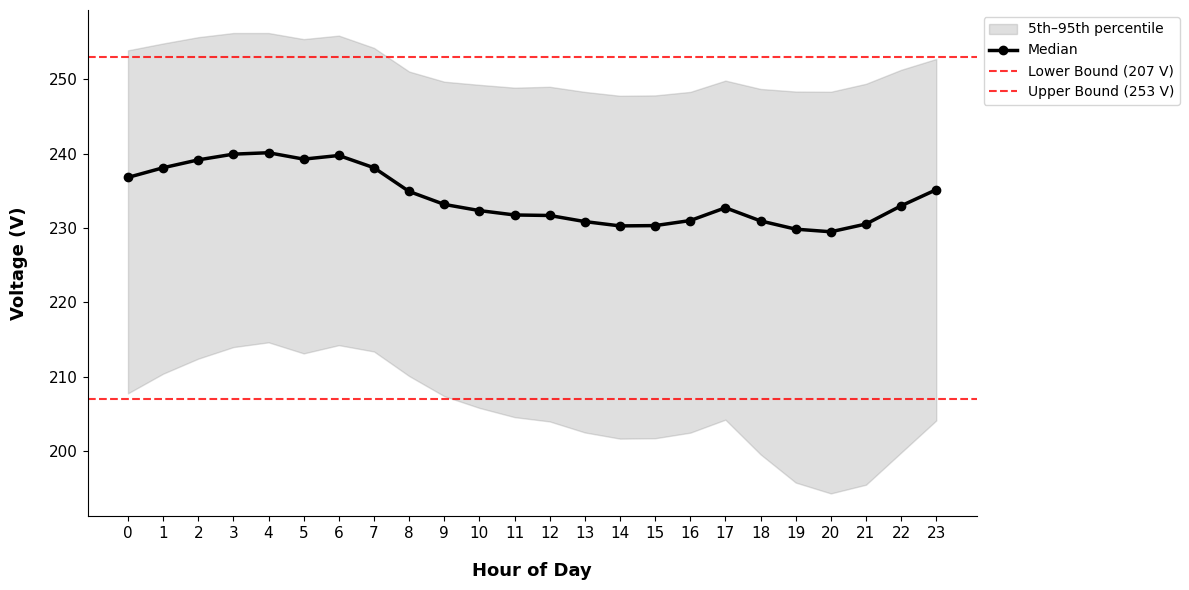

In [34]:
summary_all_hour = plot_voltage_by_hour_of_day(
    combined_hourly_voltage_df,
    cesi_level = None,
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    # ylim=(180, 260), 
    legend_loc='upper left',
    legend_bbox=(1, 1)
)

### Hour of day plots (`by month`)  

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_monthly_hour_of_day_profiles(
    df,
    site_ids=None,
    cesi_level=None,          # 'Low', 'High', or None
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    months=None,
    figsize=(14, 10),
    ncols=3,
    linewidth=2.5,
    alpha_band=0.25,
    line_color=None,
    band_color=None,
    ylabel='Voltage (V)',
    xlabel='Hour of Day',
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.2,
    sharey=True,
    ylim=None
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if cesi_level is not None:
        plot_df = plot_df[plot_df['cesi_level'] == cesi_level]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['time', 'voltage'])

    cesi_colors = {
        'Low': {'line': '#6a51a3', 'band': '#bcbddc'},
        'Medium': {'line': '#238b45', 'band': '#a1d99b'},
        'High': {'line': '#8c2d04', 'band': '#fdbb84'}
    }

    if line_color is None:
        line_color = cesi_colors.get(cesi_level, {}).get('line', 'black')

    if band_color is None:
        band_color = cesi_colors.get(cesi_level, {}).get('band', 'gray')

    plot_df['hour'] = plot_df['time'].dt.hour
    plot_df['month'] = plot_df['time'].dt.month
    plot_df['month_name'] = plot_df['time'].dt.month_name().str[:3]

    if months is not None:
        plot_df = plot_df[plot_df['month'].isin(months)]

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    grouped = (
        plot_df
        .groupby(['month', 'month_name', 'hour'])['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
    )

    month_order = [
        'Jan', 'Feb', 'Mar', 'Apr',
        'May', 'Jun', 'Jul', 'Aug',
        'Sep', 'Oct', 'Nov', 'Dec'
    ]

    grouped['month_name'] = pd.Categorical(
        grouped['month_name'],
        categories=month_order,
        ordered=True
    )

    grouped = grouped.sort_values(['month', 'hour'])

    unique_months = (
        grouped[['month', 'month_name']]
        .drop_duplicates()
        .sort_values('month')
    )

    n_months = len(unique_months)
    nrows = int(np.ceil(n_months / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).flatten()

    lower_bound = nominal_voltage * (1 - tolerance)
    upper_bound = nominal_voltage * (1 + tolerance)

    for i, (_, row) in enumerate(unique_months.iterrows()):

        month_num = row['month']
        month_name = row['month_name']
        ax = axes[i]

        month_df = grouped[grouped['month'] == month_num]

        ax.fill_between(
            month_df['hour'],
            month_df['lower'],
            month_df['upper'],
            color=band_color,
            alpha=alpha_band
        )

        ax.plot(
            month_df['hour'],
            month_df['center_value'],
            color=line_color,
            linewidth=linewidth
        )

        if show_voltage_bounds:

            ax.axhline(
                lower_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

            ax.axhline(
                upper_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title(
            month_name,
            fontsize=13,
            fontweight='bold'
        )

        ax.set_xticks(range(0, 24, 4))
        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        sns.despine(ax=ax)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    title_prefix = f'{cesi_level} CESI | ' if cesi_level is not None else ''

    fig.suptitle(
        f'{title_prefix}Monthly Hour-of-Day Voltage Profiles',
        fontsize=15,
        fontweight='bold',
        y=1.02
    )

    fig.supxlabel(
        xlabel,
        fontsize=14,
        fontweight='bold',
        y=-0.02
    )

    fig.supylabel(
        ylabel,
        fontsize=14,
        fontweight='bold',
        x=-0.02
    )

    plt.tight_layout()
    plt.show()

    return grouped

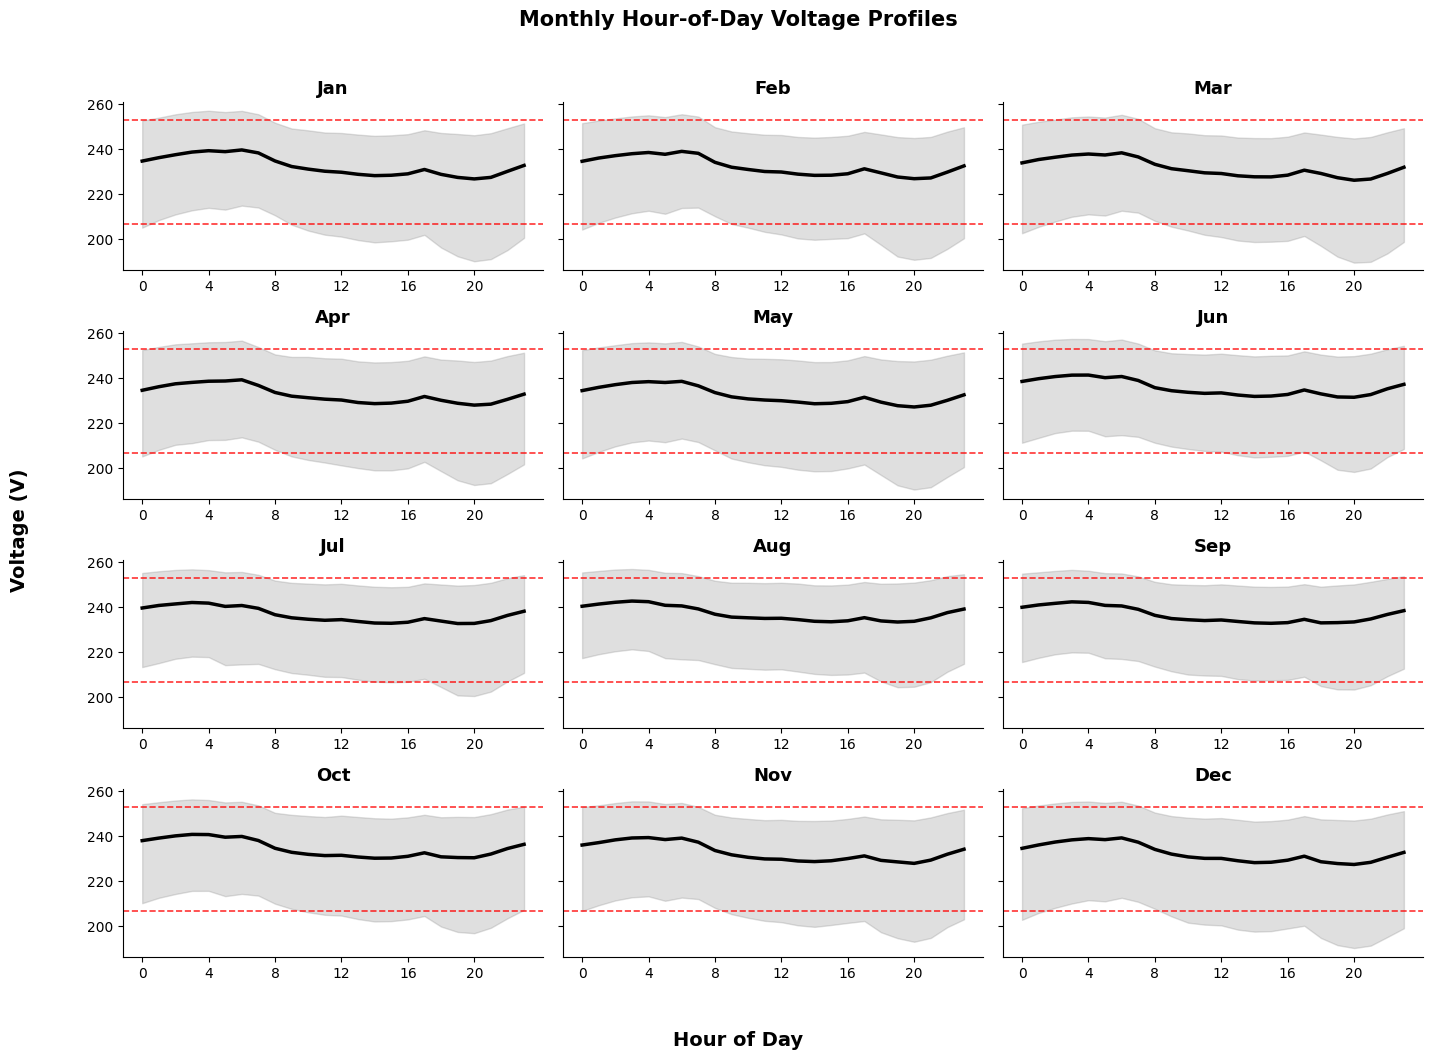

In [36]:
monthly_all = plot_monthly_hour_of_day_profiles(
    combined_hourly_voltage_df,
    cesi_level = None,
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    # ylim=(180, 260)
)

### Hour of day plots (`by Quarter`)  

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_quarterly_hour_of_day_profiles(
    df,
    site_ids=None,
    cesi_level=None,          # 'Low', 'High', or None
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    figsize=(14, 8),
    ncols=2,
    linewidth=2.5,
    alpha_band=0.25,
    line_color=None,
    band_color=None,
    ylabel='Voltage (V)',
    xlabel='Hour of Day',
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.2,
    sharey=True,
    ylim=None
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if cesi_level is not None:
        plot_df = plot_df[plot_df['cesi_level'] == cesi_level]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['time', 'voltage'])

    cesi_colors = {
        'Low': {'line': '#6a51a3', 'band': '#bcbddc'},
        'Medium': {'line': '#238b45', 'band': '#a1d99b'},
        'High': {'line': '#8c2d04', 'band': '#fdbb84'}
    }

    if line_color is None:
        line_color = cesi_colors.get(cesi_level, {}).get('line', 'black')

    if band_color is None:
        band_color = cesi_colors.get(cesi_level, {}).get('band', 'gray')

    plot_df['hour'] = plot_df['time'].dt.hour
    plot_df['quarter'] = plot_df['time'].dt.quarter
    plot_df['quarter_label'] = 'Q' + plot_df['quarter'].astype(str)

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    grouped = (
        plot_df
        .groupby(['quarter', 'quarter_label', 'hour'])['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
        .sort_values(['quarter', 'hour'])
    )

    unique_quarters = (
        grouped[['quarter', 'quarter_label']]
        .drop_duplicates()
        .sort_values('quarter')
    )

    n_quarters = len(unique_quarters)
    nrows = int(np.ceil(n_quarters / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).flatten()

    lower_bound = nominal_voltage * (1 - tolerance)
    upper_bound = nominal_voltage * (1 + tolerance)

    for i, (_, row) in enumerate(unique_quarters.iterrows()):

        quarter_num = row['quarter']
        quarter_label = row['quarter_label']

        ax = axes[i]

        quarter_df = grouped[grouped['quarter'] == quarter_num]

        ax.fill_between(
            quarter_df['hour'],
            quarter_df['lower'],
            quarter_df['upper'],
            color=band_color,
            alpha=alpha_band
        )

        ax.plot(
            quarter_df['hour'],
            quarter_df['center_value'],
            color=line_color,
            linewidth=linewidth
        )

        if show_voltage_bounds:

            ax.axhline(
                lower_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

            ax.axhline(
                upper_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title(
            quarter_label,
            fontsize=14,
            fontweight='bold'
        )

        ax.set_xticks(range(0, 24, 4))

        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        sns.despine(ax=ax)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    title_prefix = f'{cesi_level} CESI | ' if cesi_level is not None else ''

    fig.suptitle(
        f'{title_prefix}Quarterly Hour-of-Day Voltage Profiles',
        fontsize=15,
        fontweight='bold',
        y=1.02
    )

    fig.supxlabel(
        xlabel,
        fontsize=14,
        fontweight='bold',
        y=-0.02
    )

    fig.supylabel(
        ylabel,
        fontsize=14,
        fontweight='bold',
        x=-0.02
    )

    plt.tight_layout()
    plt.show()

    return grouped

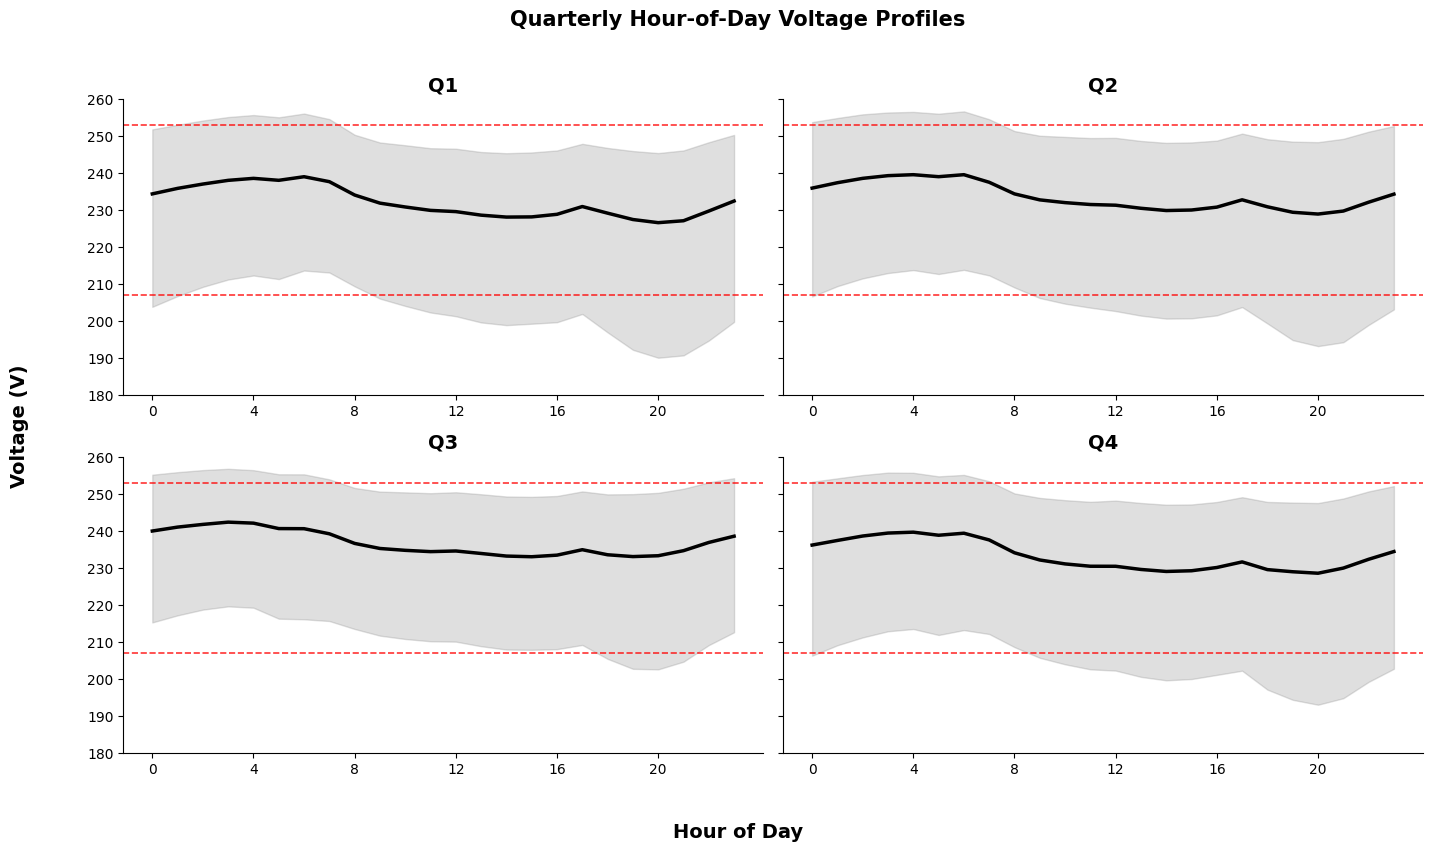

In [38]:
quarterly_all = plot_quarterly_hour_of_day_profiles(
    combined_hourly_voltage_df,
    cesi_level = None,
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    ylim=(180, 260)
)

### Hour of day plots (`by Season`)  

In [39]:
def plot_seasonal_hour_of_day_profiles(
    df,
    season_col='season_detailed',   # or 'season_simple'
    site_ids=None,
    cesi_level=None,
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    figsize=(14, 8),
    ncols=2,
    linewidth=2.5,
    alpha_band=0.25,
    line_color=None,
    band_color=None,
    ylabel='Voltage (V)',
    xlabel='Hour of Day',
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.2,
    sharey=True,
    ylim=None,
    season_order=None,
    season_label_map=None
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if cesi_level is not None:
        plot_df = plot_df[plot_df['cesi_level'] == cesi_level]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['time', 'voltage', season_col])

    cesi_colors = {
        'Low': {'line': '#6a51a3', 'band': '#bcbddc'},
        'Medium': {'line': '#238b45', 'band': '#a1d99b'},
        'High': {'line': '#8c2d04', 'band': '#fdbb84'}
    }

    if line_color is None:
        line_color = cesi_colors.get(cesi_level, {}).get('line', 'black')

    if band_color is None:
        band_color = cesi_colors.get(cesi_level, {}).get('band', 'gray')

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    plot_df['hour'] = plot_df['time'].dt.hour

    if season_order is None:
        if season_col == 'season_detailed':
            season_order = [
                'Dry_Season',
                'Major_Rainy_Season',
                'Minor_Rainy_Season',
                'Transition_Season'
            ]
        else:
            season_order = [
                'Dry_Season',
                'Rainy_Season',
                'Transition_Season'
            ]

    if season_label_map is None:
        season_label_map = {
            'Dry_Season': 'Dry Season',
            'Major_Rainy_Season': 'Major Rainy Season',
            'Minor_Rainy_Season': 'Minor Rainy Season',
            'Transition_Season': 'Transition Season',
            'Rainy_Season': 'Rainy Season'
        }

    plot_df = plot_df[plot_df[season_col].isin(season_order)]

    grouped = (
        plot_df
        .groupby([season_col, 'hour'])['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
    )

    grouped[season_col] = pd.Categorical(
        grouped[season_col],
        categories=season_order,
        ordered=True
    )

    grouped = grouped.sort_values([season_col, 'hour'])

    seasons_present = [
        s for s in season_order
        if s in grouped[season_col].dropna().astype(str).unique()
    ]

    n_seasons = len(seasons_present)
    nrows = int(np.ceil(n_seasons / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).flatten()

    lower_bound = nominal_voltage * (1 - tolerance)
    upper_bound = nominal_voltage * (1 + tolerance)

    for i, season in enumerate(seasons_present):

        ax = axes[i]
        season_df = grouped[grouped[season_col] == season]

        ax.fill_between(
            season_df['hour'],
            season_df['lower'],
            season_df['upper'],
            color=band_color,
            alpha=alpha_band
        )

        ax.plot(
            season_df['hour'],
            season_df['center_value'],
            color=line_color,
            linewidth=linewidth
        )

        if show_voltage_bounds:
            ax.axhline(
                lower_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

            ax.axhline(
                upper_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title(
            season_label_map.get(season, season),
            fontsize=14,
            fontweight='bold'
        )

        ax.set_xticks(range(0, 24, 4))
        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        sns.despine(ax=ax)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    title_prefix = f'{cesi_level} CESI | ' if cesi_level is not None else ''

    fig.suptitle(
        f'{title_prefix}Seasonal Hour-of-Day Voltage Profiles',
        fontsize=15,
        fontweight='bold',
        y=1.02
    )

    fig.supxlabel(
        xlabel,
        fontsize=14,
        fontweight='bold',
        y=-0.02
    )

    fig.supylabel(
        ylabel,
        fontsize=14,
        fontweight='bold',
        x=-0.02
    )

    plt.tight_layout()
    plt.show()

    return grouped

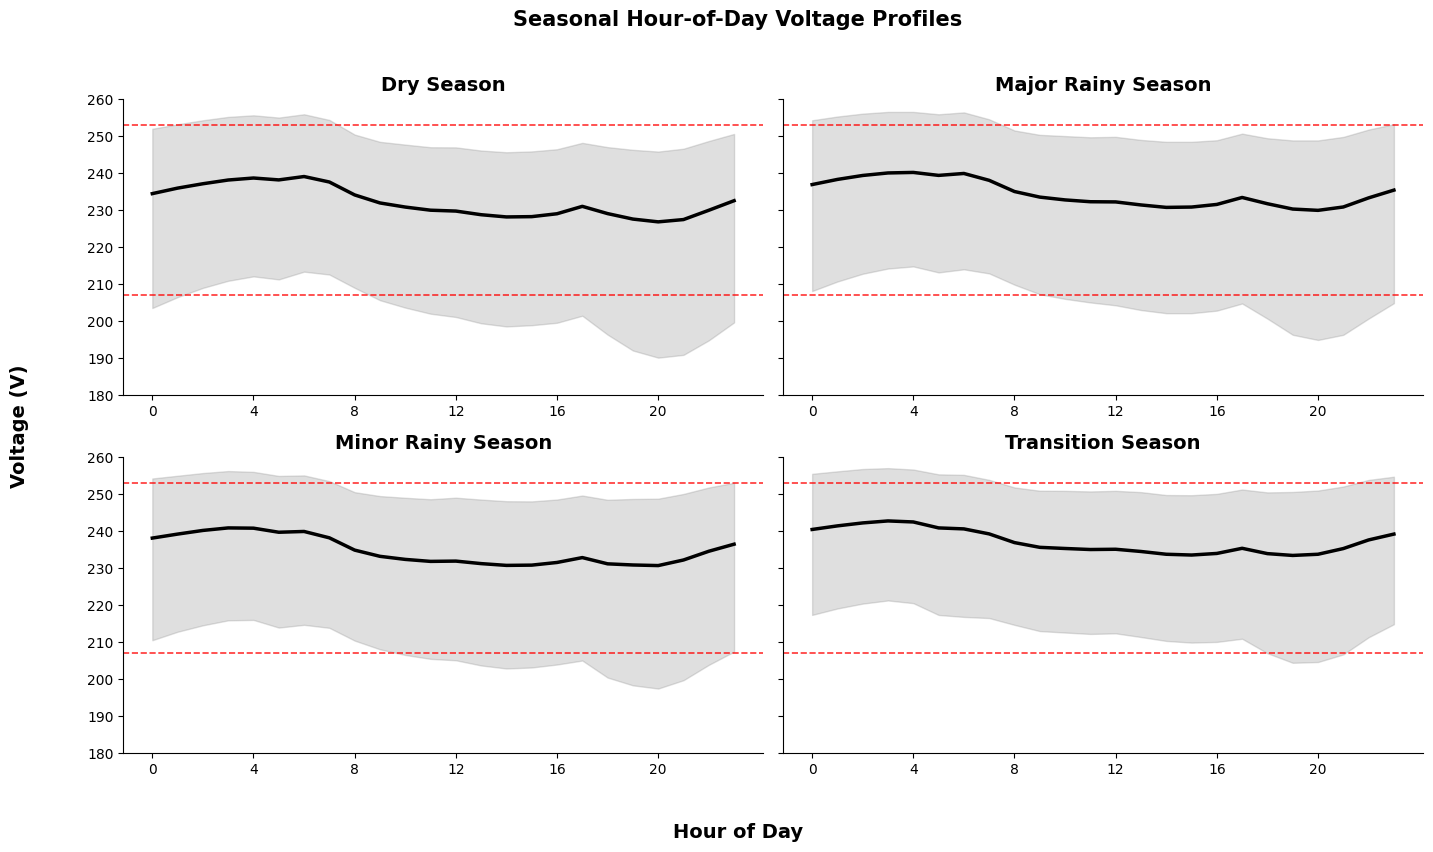

In [40]:
grouped_season = plot_seasonal_hour_of_day_profiles(
    combined_hourly_voltage_df,
    season_col='season_detailed',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    cesi_level=None, 
    ylim=(180, 260)
)

### Plain hourly - `by Quarter` 

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_quarterly_elapsed_hour_profiles(
    df,
    site_ids=None,
    cesi_level=None,
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    figsize=(14, 8),
    ncols=2,
    linewidth=2.5,
    alpha_band=0.25,
    line_color=None,
    band_color=None,
    ylabel='Voltage (V)',
    xlabel='Elapsed Hour in Quarter',
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.2,
    sharey=True,
    ylim=None
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if cesi_level is not None:
        plot_df = plot_df[plot_df['cesi_level'] == cesi_level]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['time', 'voltage'])

    cesi_colors = {
        'Low': {'line': '#6a51a3', 'band': '#bcbddc'},
        'Medium': {'line': '#238b45', 'band': '#a1d99b'},
        'High': {'line': '#8c2d04', 'band': '#fdbb84'}
    }

    if line_color is None:
        line_color = cesi_colors.get(cesi_level, {}).get('line', 'black')

    if band_color is None:
        band_color = cesi_colors.get(cesi_level, {}).get('band', 'gray')

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    # -------------------------
    # Quarter + elapsed hour
    # -------------------------
    plot_df['quarter'] = plot_df['time'].dt.quarter
    plot_df['quarter_label'] = 'Q' + plot_df['quarter'].astype(str)

    plot_df['quarter_start'] = (
        plot_df['time']
        .dt.to_period('Q')
        .dt.start_time
    )

    plot_df['elapsed_hour_in_quarter'] = (
        (plot_df['time'] - plot_df['quarter_start'])
        .dt.total_seconds()
        / 3600
    ).astype(int)

    # -------------------------
    # Aggregate by quarter and elapsed hour
    # Pools 2022 + 2023 together
    # -------------------------
    grouped = (
        plot_df
        .groupby(
            ['quarter', 'quarter_label', 'elapsed_hour_in_quarter']
        )['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
        .sort_values(['quarter', 'elapsed_hour_in_quarter'])
    )

    unique_quarters = (
        grouped[['quarter', 'quarter_label']]
        .drop_duplicates()
        .sort_values('quarter')
    )

    n_quarters = len(unique_quarters)
    nrows = int(np.ceil(n_quarters / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).flatten()

    lower_bound = nominal_voltage * (1 - tolerance)
    upper_bound = nominal_voltage * (1 + tolerance)

    for i, (_, row) in enumerate(unique_quarters.iterrows()):

        quarter_num = row['quarter']
        quarter_label = row['quarter_label']

        ax = axes[i]

        quarter_df = grouped[
            grouped['quarter'] == quarter_num
        ]

        ax.fill_between(
            quarter_df['elapsed_hour_in_quarter'],
            quarter_df['lower'],
            quarter_df['upper'],
            color=band_color,
            alpha=alpha_band
        )

        ax.plot(
            quarter_df['elapsed_hour_in_quarter'],
            quarter_df['center_value'],
            color=line_color,
            linewidth=linewidth
        )

        if show_voltage_bounds:

            ax.axhline(
                lower_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

            ax.axhline(
                upper_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title(
            quarter_label,
            fontsize=14,
            fontweight='bold'
        )

        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        sns.despine(ax=ax)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    title_prefix = f'{cesi_level} CESI | ' if cesi_level is not None else ''

    fig.suptitle(
        f'{title_prefix}Quarterly Voltage Profiles',
        fontsize=15,
        fontweight='bold',
        y=1.02
    )

    fig.supxlabel(
        xlabel,
        fontsize=14,
        fontweight='bold',
        y=-0.02
    )

    fig.supylabel(
        ylabel,
        fontsize=14,
        fontweight='bold',
        x=-0.02
    )

    plt.tight_layout()
    plt.show()

    return grouped

In [42]:
# quarter_elapsed_all = plot_quarterly_elapsed_hour_profiles(
#     combined_hourly_voltage_df,
#     cesi_level = None,
#     center='median',
#     lower_q=0.05,
#     upper_q=0.95,
#     ylim=(180, 260)
# )